In [3]:
import numpy as np
import matplotlib.pyplot as plt
import jax

from utils import *
from model_definition.network_model_utils import *
from tvboptim.types import Parameter, BoundedParameter

jax.config.update("jax_enable_x64", True)

Cache stored here: c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\cache\ei_tuning


In [4]:
# Set directory information
data_dir = "./"
cond0_filename = "TS_Control.npy"
cond1_filename = "TS_Schizo.npy"

# Set dataset parameters
n_sub = 48
n_nodes = 68 # size of network for AAL90
conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

# Simulation parameters
t1 = 314_000   # Simulation duration (ms) matching empirical data (=304_000) + transient time (~10_000 ms)
dt = 4.0      # Integration timestep (ms) matching original script
bold_TR = 2000.0 # BOLD sampling period (ms)
target_fic = 0.25  # FIC tuning parameter: Target excitatory activity level

# Gradient descent parameters
learning_rate = 0.0325
max_steps = 120

# Other parameters
n_tau = 2 # number of lags for lagged FC

### Load time-series BOLD data 

In [5]:
new_array = load_and_organize_bold(data_dir = data_dir, cond0_filename = cond0_filename, cond1_filename = cond1_filename,
                                   n_sub = n_sub, n_nodes = n_nodes)

### Compute time-lagged matrices

In [6]:
Q0_emp_all = np.zeros((n_sub, n_tau, n_nodes, n_nodes, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
Q1_emp_all = np.zeros((n_sub, n_tau, n_nodes, n_nodes, n_cond))

for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        # Get empirical time series of interest 
        ts = new_array[participant_idx,:,:,condition_idx]
        # Take the transpose for the lagged FC matrices computation
        X_emp = ts.T
    
        # Z-score the empirical time series per region
        z_scored_emp = z_score_per_region(X_emp)

        # Compute empirical lagged FC matrices
        Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=True)
        Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
        Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

        Q0_emp_all[participant_idx, :, :, :, condition_idx] = Q0_emp_single
        Q1_emp_all[participant_idx, :, :, :, condition_idx] = Q1_emp_single
    
print("Empirical time series shape (time points x regions):", X_emp.shape)
print("Empirical FC0 shape (regions x regions):", Q0_emp_all.shape)
print("Empirical FC1 shape (regions x regions):", Q1_emp_all.shape)

Empirical time series shape (time points x regions): (152, 68)
Empirical FC0 shape (regions x regions): (48, 2, 68, 68, 2)
Empirical FC1 shape (regions x regions): (48, 2, 68, 68, 2)


### Plot Q0 and Q1 for two subjects

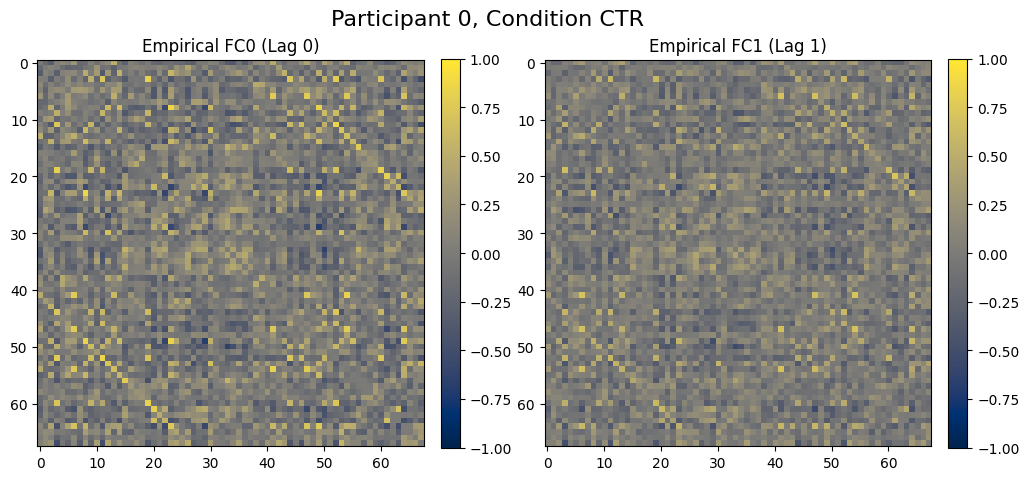

In [7]:
subj_plot_index = 0  # Index for the participant and condition to plot
cond_plot_index = 0  # Index for the condition to plot

Q0_emp_plot = Q0_emp_all[subj_plot_index, 0, :, :, cond_plot_index]  # FC0 for the selected participant and condition
Q1_emp_plot = Q1_emp_all[subj_plot_index, 1, :, :, cond_plot_index]  # Q1 for the selected participant and condition

# Plot Q 0 and Q 1 for both empirical and simulated data
fig, axes = plt.subplots(1,2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0].imshow(Q0_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1].imshow(Q1_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[1].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.suptitle(f'Participant {subj_plot_index}, Condition {conds[cond_plot_index]}', fontsize=16, y=0.739)
plt.show()

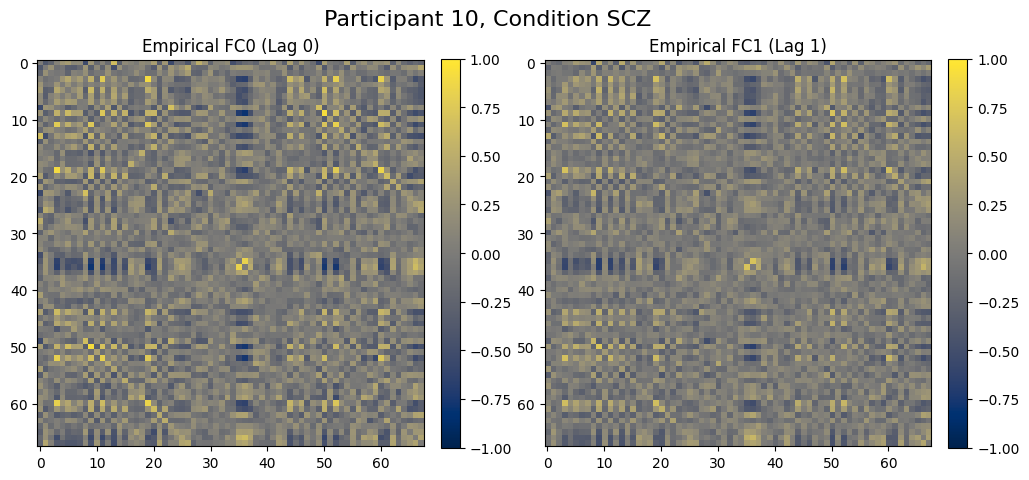

In [8]:
subj_plot_index = 10  # Index for the participant and condition to plot -> from 0 to 47
cond_plot_index = 1  # Index for the condition to plot -> 0 or 1

Q0_emp_plot = Q0_emp_all[subj_plot_index, 0, :, :, cond_plot_index]  # FC0 for the selected participant and condition
Q1_emp_plot = Q1_emp_all[subj_plot_index, 1, :, :, cond_plot_index]  # FC1 for the selected participant and condition

# Plot FC 0 and FC 1 for both empirical and simulated data
fig, axes = plt.subplots(1,2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0].imshow(Q0_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1].imshow(Q1_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[1].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.suptitle(f'Participant {subj_plot_index}, Condition {conds[cond_plot_index]}', fontsize=16, y=0.739)
plt.show()

### Load structural connectivity data

In [9]:
sc_path = 'SC_EnigmadK68.mat'
tl_path = 'tract_lengths.csv'
centers_path = 'centers.txt'

weights, delays, labels = load_structural_connectivity(sc_filepath=sc_path, tl_filepath=tl_path, centers_filepath=centers_path)

### Build the model to optimize

In [10]:
# Build a single network model using the structural connectivity and region labels
network = build_network_model(weights=weights, labels=labels)

Network created with 68 nodes


### Run initial simulation

In [11]:
model, state, result_init = run_initial_simulation(t1=t1, dt=dt, network=network)

Running initial transient simulation...
Initial simulation complete. Final S_e mean: 0.856
Initial simulation complete. Final S_i mean: 0.949


### Set up BOLD monitor

In [12]:
bold_monitor_opt = setup_bold_monitor(bold_TR = bold_TR, result_init = result_init)

BOLD monitor initialized


In [13]:
network.update_history(result_init)

model_opt, state_opt, _ = run_initial_simulation(t1=t1, dt=dt, network = network, verbose=False)

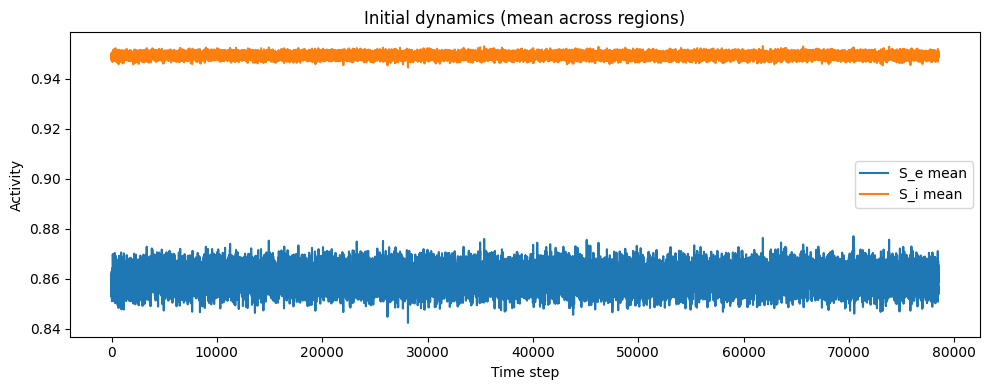

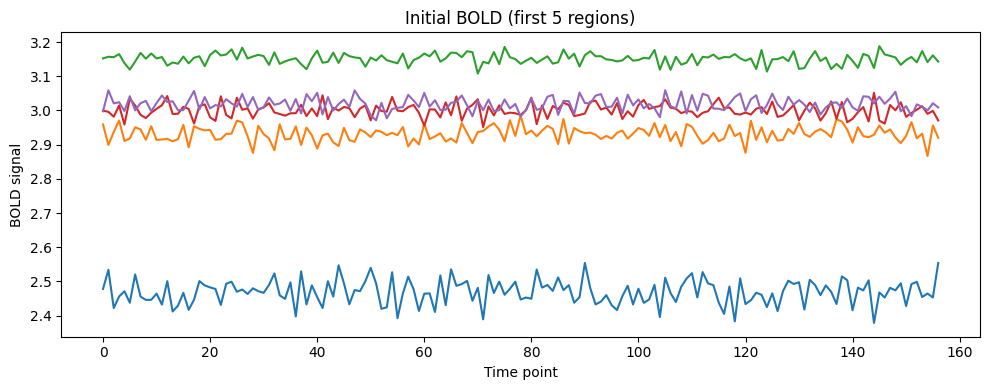

In [14]:
# Quick sanity check: plot mean S_e/S_i and BOLD after the initial model_opt setup
ts_check = model_opt(state_opt)
s_e_mean = jnp.mean(ts_check.data[:, 0, :], axis=1)
s_i_mean = jnp.mean(ts_check.data[:, 1, :], axis=1)

plt.figure(figsize=(10, 4))
plt.plot(s_e_mean, label="S_e mean")
plt.plot(s_i_mean, label="S_i mean")
plt.title("Initial dynamics (mean across regions)")
plt.xlabel("Time step")
plt.ylabel("Activity")
plt.legend()
plt.tight_layout()
plt.show()

bold_check = bold_monitor_opt(ts_check)
bold_signal = bold_check.data.reshape(bold_check.data.shape[0], bold_check.data.shape[-1])
plt.figure(figsize=(10, 4))
plt.plot(bold_signal[:, :5])
plt.title("Initial BOLD (first 5 regions)")
plt.xlabel("Time point")
plt.ylabel("BOLD signal")
plt.tight_layout()
plt.show()

In [15]:
Q0_emp = Q0_emp_all[0, 0, :, :, 0]  # FC0 for the first participant and first condition
Q1_emp = Q1_emp_all[0, 1, :, :,0]
                        
loss = make_loss(
    model_opt=model_opt,
    bold_monitor_opt=bold_monitor_opt,
    Q0_emp=Q0_emp,
    Q1_emp=Q1_emp,
    target_fic=target_fic,
    alpha_fc0=1.0,
    beta_fc1=2.0
)

# Evaluate initial loss
initial_loss = loss(state_opt)
print(f"Initial loss: {initial_loss:.4f}")

# Mark parameters for optimization (J_i, wLRE, wFFI) with appropriate constraints
state_opt.dynamics.J_i = Parameter(state_opt.dynamics.J_i)
state_opt.coupling.coupling.wLRE = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)
state_opt.coupling.coupling.wFFI = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)

Initial loss: 1.0224


In [ ]:
# Single loss with heavier FC1

beta_fc1 = 2.0
alpha_fc0 = 1.0

def loss(state):
    ts = model_opt(state)
    bold = bold_monitor_opt(ts)

    jax.debug.print("Bold average signal (first 5 regions): {bold_avg}", bold_avg=jnp.mean(bold.data[:, :5], axis=0))
    
    bold_signal = bold.data
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    bold_signal = bold_signal[5:, :]
    z_scored_bold = z_score_per_region(bold_signal)

    Qsim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim, Q1_sim = Qsim[0], Qsim[1]

    loss_q0 = rmse(Q0_sim, Q0_emp)
    loss_q1 = rmse(Q1_sim, Q1_emp)

    mean_activity = jnp.mean(ts.data[-500:, 0, :], axis=0)
    activity_loss = jnp.mean((mean_activity - target_fic) ** 2)

    total_loss = alpha_fc0 * loss_q0 + beta_fc1 * loss_q1 + activity_loss

    # Safe debug print inside JAX-traced code (no f-string formatting)
    # jax.debug.print(
    #     "Loss components - FC0: {q0:.4f}, FC1: {q1:.4f}, Activity: {act:.6f}",
    #     q0=loss_q0,
    #     q1=loss_q1,
    #     act=activity_loss,
    # )

    return total_loss

In [16]:
# Create optimizer
optimizer = OptaxOptimizer(
    loss,
    optax.adamaxw(learning_rate=learning_rate),
    callback=MultiCallback([DefaultPrintCallback(), SavingLossCallback()])
)


In [17]:
optimized_state, optimized_fit = run_gradient_optimization(max_steps, learning_rate, loss, state_opt)

Running computations for gradient_optimization
LR: 0.0325
Step 0: 1.022387
Step 1: 0.990873


KeyboardInterrupt: 

In [15]:
optimized_state, optimized_fit = optimizer.run(state_opt, max_steps=max_steps)

Step 0: 1.022387
Step 1: 0.990873
Step 2: 0.949785


KeyboardInterrupt: 

In [85]:
import copy 

# Will be populated after initial simulation completes
model_eval, state_eval, _state = None, None, None

def setup_eval_model():
    """Setup evaluation model for FC computation (called after initial simulation)."""
    global model_eval, state_eval, _state
    model_eval, state_eval = prepare(network, Heun(), t1=t1, dt=dt)
    _state = copy.deepcopy(state_eval)

def compute_z_scored_bold(model, state):
    # Run simulation
    raw_result = model(state)

    # Compute BOLD
    bold_result = bold_monitor_opt(raw_result)
    bold_signal = bold_result.data
    # Reshape from (time points, 1, regions) to (time points, regions) 
    n_timepoints, n_nodes = bold_signal.shape[0], bold_signal.shape[-1]
    bold_signal = bold_signal.reshape(n_timepoints, n_nodes)
    # Remove transient (5 time points = 20 ms, given dt=4 ms)
    bold_signal = bold_signal[5:, :]
    z_scored_bold = z_score_per_region(bold_signal)
    return z_scored_bold

def eval_Q0_Q1(model_eval, state_eval):
    """Evaluate FC0 and FC1 for given parameters using a long simulation."""
    z_scored_bold = compute_z_scored_bold(model_eval, state_eval)

    Q_sim = lagged_fc_matrices(z_scored_bold, n_tau=2, diag_zero=True)
    Q0_sim = Q_sim[0]  # Extract FC0 (lag-0)
    Q1_sim = Q_sim[1]  # Extract FC1 (lag-1)
    
    return Q0_sim, Q1_sim

transient_lim = 5  # Number of initial time points to remove from BOLD signal

print("Utility functions defined")

Utility functions defined


In [ ]:
# Run this cell if running gradient descent only
#  Setup evaluation model
setup_eval_model()

# Compute Q before gradient descent optimization
print("Computing pre-gradient descent functional connectivity...")
Q0_pre_gd, Q1_pre_gd = eval_Q0_Q1(
    model_eval, state_eval
)

# Compute quality metrics
Q0_corr_pre = fc_corr(Q0_pre_gd, Q0_emp)
Q0_rmse_pre = jnp.sqrt(jnp.mean((Q0_pre_gd - Q0_emp)**2))
Q1_corr_pre = fc_corr(Q1_pre_gd, Q1_emp)
Q1_rmse_pre = jnp.sqrt(jnp.mean((Q1_pre_gd - Q1_emp)**2))

Computing pre-gradient descent functional connectivity...


In [87]:
z_scored_gd = compute_z_scored_bold(
    model_opt,
    optimized_state
)

In [ ]:
# Compute simulated lagged FC matrices
Q_sim = lagged_fc_matrices(z_scored_gd, n_tau=2, diag_zero=True)
Q0_sim = Q_sim[0]  # Simulated FC0
Q1_sim = Q_sim[1]  # Simulated FC1

Q0_corr_opt = fc_corr(Q0_sim, Q0_emp)
Q1_corr_opt = fc_corr(Q1_sim, Q1_emp)

Q0_rmse_opt = jnp.sqrt(jnp.mean((Q0_sim - Q0_emp)**2))
Q1_rmse_opt = jnp.sqrt(jnp.mean((Q1_sim - Q1_emp)**2))

In [ ]:
print(f"\nOptimization Results for FC0:")
print(f"  Pre-Optimization  - Correlation: {Q0_corr_pre:.4f}, RMSE: {Q0_rmse_pre:.4f}")
print(f"  Post-Optimization - Correlation: {Q0_corr_opt:.4f}, RMSE: {Q0_rmse_opt:.4f}")
print(f"  Improvement: Δcorr = {Q0_corr_opt - Q0_corr_pre:+.4f}, ΔRMSE = {Q0_rmse_opt - Q0_rmse_pre:+.4f}")

print(f"\nOptimization Results for FC1:")
print(f"  Pre-Optimization  - Correlation: {Q1_corr_pre:.4f}, RMSE: {Q1_rmse_pre:.4f}")
print(f"  Post-Optimization - Correlation: {Q1_corr_opt:.4f}, RMSE: {Q1_rmse_opt:.4f}")
print(f"  Improvement: Δcorr = {Q1_corr_opt - Q1_corr_pre:+.4f}, ΔRMSE = {Q1_rmse_opt - Q1_rmse_pre:+.4f}")


Optimization Results for FC0:
  Pre-Optimization  - Correlation: 0.0255, RMSE: 0.2430
  Post-Optimization - Correlation: 0.8706, RMSE: 0.1233
  Improvement: Δcorr = +0.8451, ΔRMSE = -0.1197

Optimization Results for FC1:
  Pre-Optimization  - Correlation: 0.0094, RMSE: 0.2017
  Post-Optimization - Correlation: 0.7680, RMSE: 0.1177
  Improvement: Δcorr = +0.7585, ΔRMSE = -0.0839


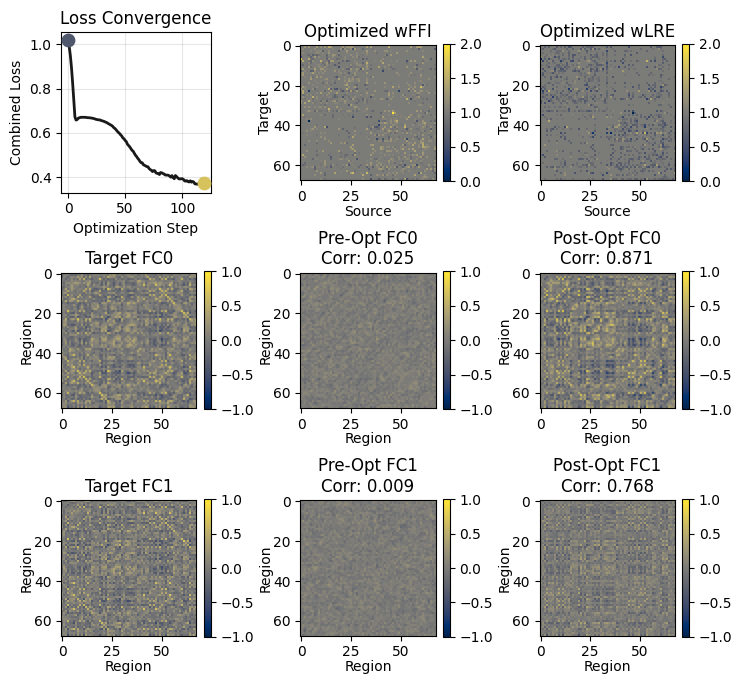

In [ ]:
# Extract loss values
loss_values = optimized_fit["loss"].save
n_steps = len(loss_values)

# Define consistent color palette derived from cividis
cividis_cmap = plt.cm.cividis
cividis_colors = cividis_cmap(np.linspace(0, 1, 256))
accent_blue = cividis_cmap(0.3)  # Dark blue from cividis
accent_gold = cividis_cmap(0.85)  # Gold/yellow from cividis
accent_mid = cividis_cmap(0.6)   # Mid-tone

fig = plt.figure(figsize=(8.1, 8))
gs = fig.add_gridspec(3, 3, hspace=0.42, wspace=0.6)

# Top left: Loss trajectory - use cividis-derived colors
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(loss_values, linewidth=2, color="k", alpha=0.9)
ax1.scatter(0, loss_values[0], s=80, color=accent_blue, zorder=5)
ax1.scatter(n_steps-1, loss_values.array[-1], s=80, color=accent_gold, zorder=5)
ax1.set_xlabel('Optimization Step')
ax1.set_ylabel('Combined Loss')
ax1.set_title('Loss Convergence')
ax1.grid(True, alpha=0.3)

# Top middle: wFFI matrix - use cividis
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(optimized_state.coupling.coupling.wFFI, vmin=0, vmax=2, cmap='cividis')
ax2.set_title('Optimized wFFI')
ax2.set_xlabel('Source', labelpad=0.5)
ax2.set_ylabel('Target', labelpad=0.5)
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Top right: wLRE matrix - use cividis
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(optimized_state.coupling.coupling.wLRE, vmin=0, vmax=2, cmap='cividis')
ax3.set_title('Optimized wLRE')
ax3.set_xlabel('Source', labelpad=0.5)
ax3.set_ylabel('Target', labelpad=0.5)
plt.colorbar(im3, ax=ax3, fraction=0.046)

# Bottom row: FC comparison - use cividis
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(Q0_emp, vmin=-1, vmax=1.0, cmap='cividis')
ax4.set_title('Target FC0')
ax4.set_xlabel('Region', labelpad=0.5)
ax4.set_ylabel('Region', labelpad=0.5)
plt.colorbar(im4, ax=ax4, fraction=0.046)

ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(Q0_pre_gd, vmin=-1, vmax=1.0, cmap='cividis')
ax5.set_title(f'Pre-Opt FC0\nCorr: {Q0_corr_pre:.3f}')
ax5.set_xlabel('Region', labelpad=0.5)
ax5.set_ylabel('Region', labelpad=0.5)
plt.colorbar(im5, ax=ax5, fraction=0.046)

ax6 = fig.add_subplot(gs[1, 2])
im6 = ax6.imshow(Q0_sim, vmin=-1, vmax=1.0, cmap='cividis')
ax6.set_title(f'Post-Opt FC0\nCorr: {Q0_corr_opt:.3f}')
ax6.set_xlabel('Region', labelpad=0.5)
ax6.set_ylabel('Region', labelpad=0.5)
plt.colorbar(im6, ax=ax6, fraction=0.046)

ax7 = fig.add_subplot(gs[2, 0])
im7 = ax7.imshow(Q1_emp, vmin=-1, vmax=1.0, cmap='cividis')
ax7.set_title('Target FC1')
ax7.set_xlabel('Region', labelpad=0.5)
ax7.set_ylabel('Region', labelpad=0.5)
plt.colorbar(im7, ax=ax7, fraction=0.046)

ax8 = fig.add_subplot(gs[2, 1])
im8 = ax8.imshow(Q1_pre_gd, vmin=-1, vmax=1.0, cmap='cividis')
ax8.set_title(f'Pre-Opt FC1\nCorr: {Q1_corr_pre:.3f}')
ax8.set_xlabel('Region', labelpad=0.5)
ax8.set_ylabel('Region', labelpad=0.5)
plt.colorbar(im8, ax=ax8, fraction=0.046)

ax9 = fig.add_subplot(gs[2, 2])
im9 = ax9.imshow(Q1_sim, vmin=-1, vmax=1.0, cmap='cividis')
ax9.set_title(f'Post-Opt FC1\nCorr: {Q1_corr_opt:.3f}')
ax9.set_xlabel('Region', labelpad=0.5)
ax9.set_ylabel('Region', labelpad=0.5)
plt.colorbar(im9, ax=ax9, fraction=0.046)

plt.show()